In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm
import shap

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.columns.to_list()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [6]:
 df.shape

(1470, 35)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df["Education"].value_counts()

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

In [11]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [12]:
df.groupby("Education")["MonthlyIncome"].sum()

Education
1     958897
2    1755914
3    3727875
4    2719296
5     397327
Name: MonthlyIncome, dtype: int64

In [13]:
df["Education"].value_counts()

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

In [14]:
for column in df.columns:
    print(f"{column}: Number of unique values {df[column].nunique()}")
    print("\n")

Age: Number of unique values 43


Attrition: Number of unique values 2


BusinessTravel: Number of unique values 3


DailyRate: Number of unique values 886


Department: Number of unique values 3


DistanceFromHome: Number of unique values 29


Education: Number of unique values 5


EducationField: Number of unique values 6


EmployeeCount: Number of unique values 1


EmployeeNumber: Number of unique values 1470


EnvironmentSatisfaction: Number of unique values 4


Gender: Number of unique values 2


HourlyRate: Number of unique values 71


JobInvolvement: Number of unique values 4


JobLevel: Number of unique values 5


JobRole: Number of unique values 9


JobSatisfaction: Number of unique values 4


MaritalStatus: Number of unique values 3


MonthlyIncome: Number of unique values 1349


MonthlyRate: Number of unique values 1427


NumCompaniesWorked: Number of unique values 10


Over18: Number of unique values 1


OverTime: Number of unique values 2


PercentSalaryHike: Number of uni

In [15]:
# since EmployeeCount, Over18 and StandardHours have only 1 unique value and EmployeeNumber has 1470 values same as the dataset
# we dont really need these features, hence dropping these columns 
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [17]:
# numerical features:
num_col = [col for col in df.columns if df[col].dtype != 'object']
num_col

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [18]:
# categorical features:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
cat_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [19]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [20]:
# No : 0, Yes : 1
label = LabelEncoder()
df["Attrition"] = label.fit_transform(df.Attrition)
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [108]:
# ------------ BIVARIATE ANALYSIS (Numerical Columns) ------------

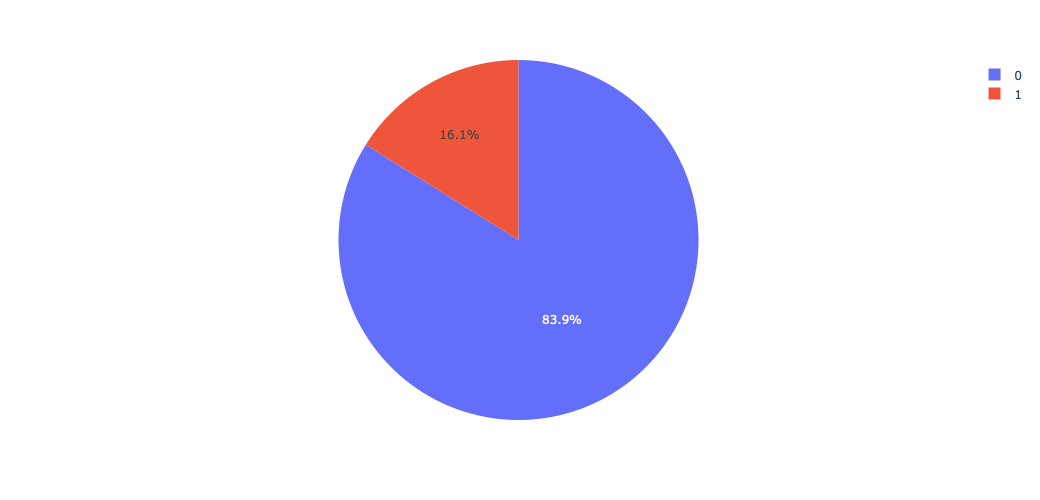

In [22]:
fig = px.pie(df, names="Attrition")
fig.update_layout(width=700, height=500)

In [23]:
fig = px.histogram(df, x="DistanceFromHome", color="Attrition",
                   title="<b>Attrition w.r.t. Distance From Home</b>"
                  )
fig.update_xaxes(title="Distance From Home")
fig.update_yaxes(title="Number of Employees")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [24]:
df['PerformanceRating'].value_counts()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

In [25]:

fig = px.histogram(
    df.assign(
        Attrition=df["Attrition"].map({
            0: "No",
            1: "Yes"
        })
    ),
    x="PerformanceRating",color="Attrition",
    title="<b>Attrition w.r.t. Performance Rating</b>"
)

fig.update_xaxes(title="Performance Rating")
fig.update_yaxes(title="Number of Employees")

fig.update_layout(width=700,height=500,bargap=0.1)

fig.show()

In [26]:
df.groupby('RelationshipSatisfaction')['Attrition'].value_counts().unstack()

Attrition,0,1
RelationshipSatisfaction,,
1,219,57
2,258,45
3,388,71
4,368,64


In [27]:
color_map = {"Yes": '#636EFA', "No": '#AB63FA'}

fig = px.histogram(df, x="RelationshipSatisfaction", color="Attrition",
                   title="<b>Attrition w.r.t. Relationship Satisfaction</b>",
                   color_discrete_map=color_map
                  )
fig.update_xaxes(title="Relationship Satisfaction")
fig.update_yaxes(title="Number of Employees")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [28]:
df['Age'].unique()

array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
       24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
       58, 20, 25, 19, 57, 52, 47, 18, 60])

In [29]:
#  Feature Engineering 

df['Age_Group'] = pd.cut(df['Age'], 
                           bins=[0, 25, 35, 45, 60],
                           labels = ["Young Employees", "Adult Employees", "Experienced Employees", "Senior Employees"],
                           include_lowest = True
                        )

In [30]:
df[['Age', 'Age_Group']].value_counts()

Age  Age_Group            
35   Adult Employees          78
34   Adult Employees          77
36   Experienced Employees    69
31   Adult Employees          69
29   Adult Employees          68
32   Adult Employees          61
30   Adult Employees          60
38   Experienced Employees    58
33   Adult Employees          58
40   Experienced Employees    57
37   Experienced Employees    50
27   Adult Employees          48
28   Adult Employees          48
42   Experienced Employees    46
39   Experienced Employees    42
45   Experienced Employees    41
41   Experienced Employees    40
26   Adult Employees          39
44   Experienced Employees    33
46   Senior Employees         33
43   Experienced Employees    32
50   Senior Employees         30
24   Young Employees          26
25   Young Employees          26
47   Senior Employees         24
49   Senior Employees         24
55   Senior Employees         22
53   Senior Employees         19
48   Senior Employees         19
51   Senior Empl

In [31]:
fig = px.histogram(df, x="Age", color="Attrition")
fig.update_layout(width=700, height=500)

fig = px.histogram(df, x='Age', color='Attrition', 
                   marginal="box",  # Add box plot on top
                   barmode='overlay',
                   opacity=0.7,
                   title='Age Distribution by Attrition')
fig.update_layout(height=600, width=800)
fig.show()

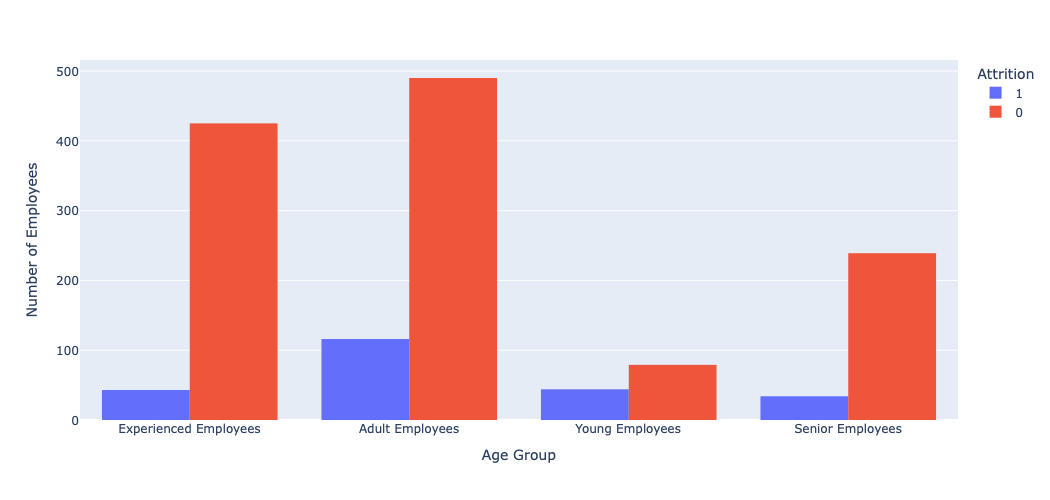

In [32]:
fig = px.histogram(df, x="Age_Group", color="Attrition", barmode="group")
fig.update_xaxes(title="Age Group")
fig.update_yaxes(title="Number of Employees")
fig.update_layout(width=700, height=500)

In [33]:
fig = px.box(df, x="Attrition", y="MonthlyIncome", 
             title='Monthly Income Distribution by Attrition')

fig.update_layout(width=700, height=500)

In [34]:
df['YearsAtCompany'].isna().sum()

np.int64(0)

In [35]:
fig = px.box(df, x="Attrition", y="YearsAtCompany")
fig.update_layout(width=700, height=500)

In [36]:
df['JobSatisfaction'].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [37]:
fig = px.histogram(
    df,
    x="JobSatisfaction",
    color="Attrition",
    barmode="group",
    title="Attrition by Job Satisfaction"
)

fig.update_xaxes(title="Job Satisfaction")
fig.update_yaxes(title="Number of Employees")
fig.update_layout(width=700, height=500)
fig.show()

In [38]:
bins = [0, 2, 6, 10, 15, 25, 40]
labels = ['Entry', 'Early', 'Mid', 'Experienced', 'Veteran', 'Senior Veteran']

df['WorkingYears_Group'] = pd.cut(df['TotalWorkingYears'], bins=bins, labels=labels, include_lowest=True)

In [39]:
df['WorkingYears_Group'].value_counts()

WorkingYears_Group
Mid               482
Early             318
Veteran           258
Experienced       191
Entry             123
Senior Veteran     98
Name: count, dtype: int64

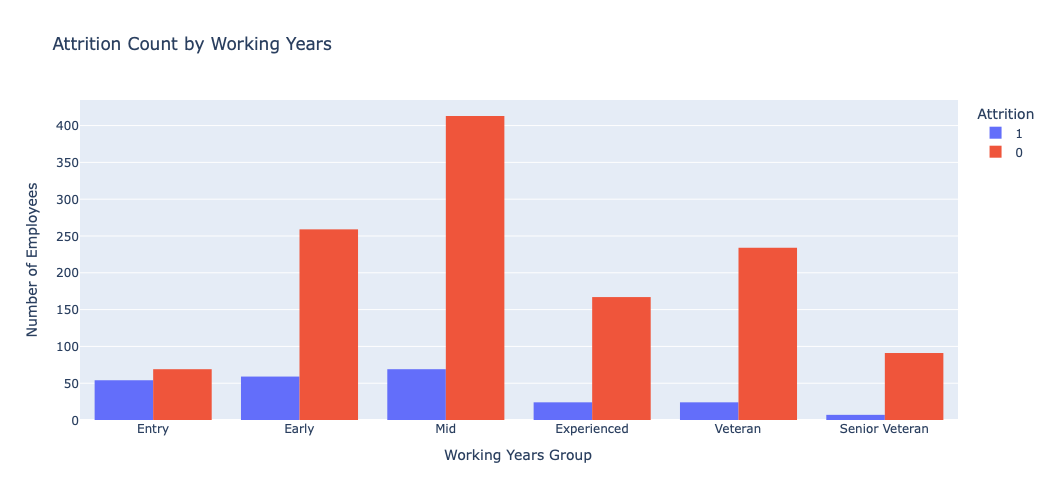

In [40]:
fig = px.histogram(df, x='WorkingYears_Group', color='Attrition',
                   barmode='group',
                   title='Attrition Count by Working Years',
                   category_orders={'WorkingYears_Group': labels})

fig.update_layout(xaxis_title='Working Years Group', yaxis_title='Number of Employees', width=700, height=500)
fig.show()

In [41]:
df['JobInvolvement'].value_counts()

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64

In [42]:
df['JobLevel'].value_counts()

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

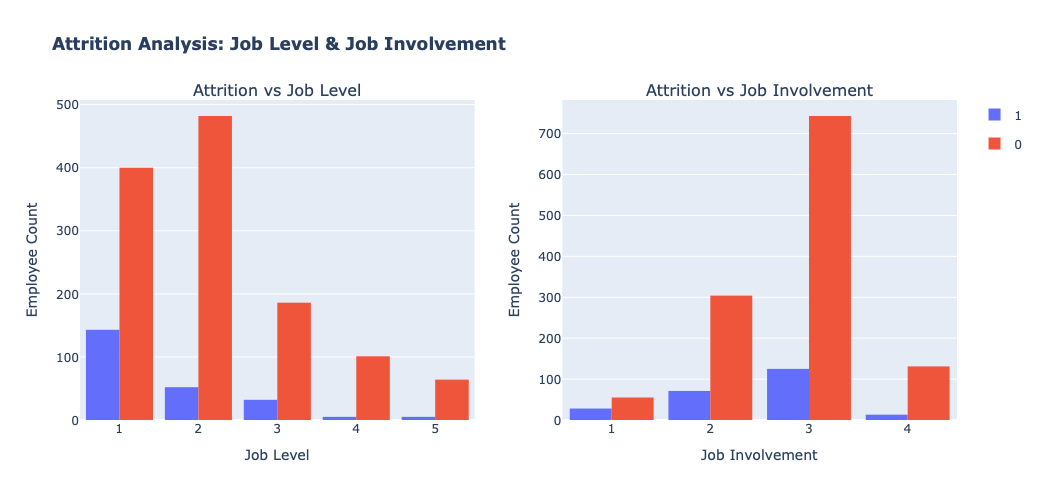

In [110]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Attrition vs Job Level", "Attrition vs Job Involvement")
)

# Job Level 
for trace in px.histogram(df, x="JobLevel", color="Attrition", barmode="group").data:
    fig.add_trace(trace, row=1, col=1)

# Job Involvement 
for trace in px.histogram(df, x="JobInvolvement", color="Attrition", barmode="group").data:
    trace.showlegend = False
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    title="<b>Attrition Analysis: Job Level & Job Involvement</b>",
    width=1000, height=500, bargap=0.15, barmode="group"
)
fig.update_xaxes(title_text="Job Level", row=1, col=1)
fig.update_xaxes(title_text="Job Involvement", row=1, col=2)
fig.update_yaxes(title_text="Employee Count")
fig.show()

In [44]:
df['YearsSinceLastPromotion'].value_counts()

YearsSinceLastPromotion
0     581
1     357
2     159
7      76
4      61
3      52
5      45
6      32
11     24
8      18
9      17
15     13
13     10
12     10
14      9
10      6
Name: count, dtype: int64

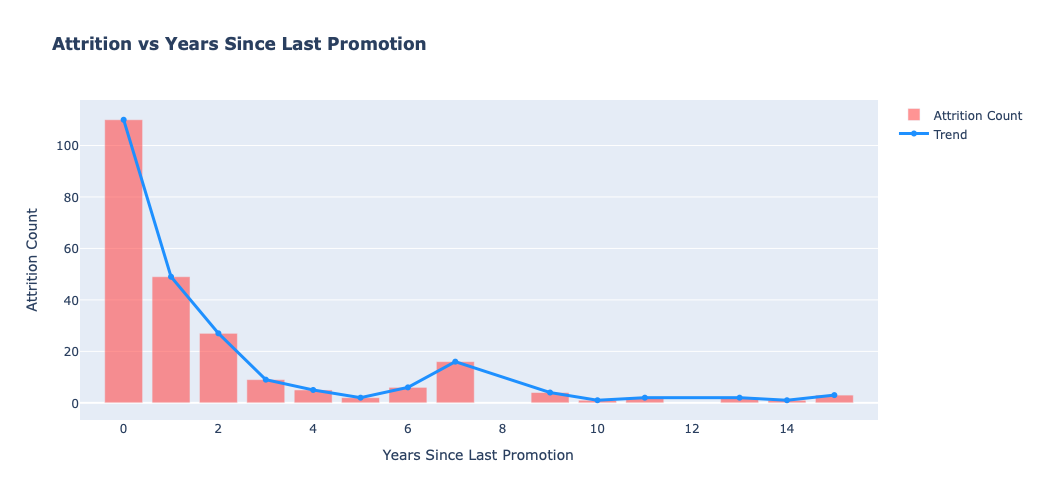

In [111]:
# Attrition = 1 only
temp = df[df["Attrition"] == 1].groupby("YearsSinceLastPromotion").size().reset_index(name="count")

fig = go.Figure()

# Bar Graph 
fig.add_trace(
    go.Bar(
        x=temp["YearsSinceLastPromotion"],
        y=temp["count"],
        name="Attrition Count",
        marker_color="#FF4D4D",
        opacity=0.6
    )
)

# Line chart 
fig.add_trace(
    go.Scatter(
        x=temp["YearsSinceLastPromotion"],
        y=temp["count"],
        mode="lines+markers",
        name="Trend",
        line=dict(color="#1E90FF", width=3)
    )
)

fig.update_layout(
    title="<b>Attrition vs Years Since Last Promotion</b>",
    xaxis_title="Years Since Last Promotion",
    yaxis_title="Attrition Count",
    width=800,
    height=500
)

fig.show()

In [46]:
df.groupby('WorkLifeBalance')['Attrition'].value_counts().unstack()

Attrition,0,1
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [47]:
fig = px.histogram(df, x='WorkLifeBalance', color='Attrition',
                   barmode='group',
                   title='Attrition Count by Work Life Balance',
                   category_orders={'WorkLifeBalance': labels})

fig.update_layout(xaxis_title='Work Life Balance', yaxis_title='Number of Employees', width=700, height=500)
fig.show() 

In [48]:
fig = px.histogram(df, x='YearsAtCompany', color='Attrition',
                   barmode='group',
                   title='Attrition Count by Years At Company',
                   category_orders={'YearsAtCompany': labels})

fig.update_layout(xaxis_title='Years At Company', yaxis_title='Number of Employees', width=700, height=500)
fig.show() 

In [49]:
fig = px.histogram(df, x='YearsInCurrentRole', color='JobRole',
                   barmode='group',
                   title='YearsInCurrentRole by JobRole',
                   category_orders={'YearsInCurrentRole': labels})

fig.update_layout(xaxis_title='Years At Company', yaxis_title='Number of Employees', width=1000, height=500)
fig.show() 

In [50]:
fig = make_subplots(
    rows=3, 
    cols=1,
    subplot_titles=(
        "Attrition by Job Role",
        "Years in Current Role by Job Role & Attrition"
    ),
    vertical_spacing=0.13
)

fig = make_subplots(rows=2, cols=1,
    subplot_titles=("Attrition by Job Role", "Years in Current Role by Job Role & Attrition"),
    vertical_spacing=0.25
                   )
# Bar Chart
for trace in px.bar(
    df.groupby(['JobRole', 'Attrition']).size().reset_index(name='Number of Employees'),
    x='JobRole',
    y='Number of Employees',
    color='Attrition',
    barmode='group',
    color_discrete_map={0: '#EF553B', 1: '#636EFA'}
).data:
    fig.add_trace(trace, row=1, col=1)
    
# Box Plot
for trace in px.box(
    df,
    x='JobRole',
    y='YearsInCurrentRole',
    color='Attrition',
    color_discrete_map={0: '#EF553B', 1: '#636EFA'}
).data:
    trace.showlegend = False
    fig.add_trace(trace, row=2, col=1)
    
fig.update_layout(
    title="<b>Job Role Analysis - Attrition & Tenure</b>",
    width=950,
    height=1000,
    barmode='group',
    legend_title="Attrition",
    template="plotly_white"
)
fig.update_xaxes(tickangle=45)
fig.update_yaxes(title_text="Number of Employees", row=1, col=1)
fig.update_yaxes(title_text="Years in Current Role", row=2, col=1)
fig.show()

In [112]:
# ------------ BIVARIATE ANALYSIS (Categorical Columns) ------------

In [52]:
cat_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [53]:
df[['BusinessTravel','Attrition']].value_counts().unstack()

Attrition,0,1
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


In [54]:
fig = make_subplots(
    rows=1, 
    cols=2,
    subplot_titles=("Overall Business Travel Distribution", 
                   "Attrition by Business Travel"),
    specs=[[{"type": "pie"}, {"type": "xy"}]]
)

# Pie Chart
for trace in px.pie(df, names="BusinessTravel").data:
    fig.add_trace(trace, row=1, col=1)

# Bar Chart
for trace in px.histogram(
    df, 
    x='BusinessTravel', 
    color='Attrition',
    barmode='stack',
    category_orders={'BusinessTravel': labels},
    color_discrete_sequence=px.colors.qualitative.Dark24
).data:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    title="<b>Business Travel Analysis</b>",
    width=1000,
    height=550, barnorm='percent',
    legend_title="Attrition",
    template="plotly_white"
)

fig.update_xaxes(title_text="Business Travel", row=1, col=2)
fig.update_yaxes(title_text="Number of Employees", row=1, col=2)

fig.show()

In [55]:
df[['Department', 'Gender']].value_counts().unstack()

Gender,Female,Male
Department,,
Human Resources,20,43
Research & Development,379,582
Sales,189,257


In [56]:
fig = px.histogram(df, x='Department', color='Attrition',
                   barmode='group',
                   title='Attrition Count by Department',
                   category_orders={'Department': labels})

fig.update_layout(xaxis_title='Department', yaxis_title='Number of Employees', width=700, height=500)
fig.show()

In [57]:
fig = px.histogram(
    df,
    x='Department',
    color='Attrition',
    barmode='group',
    facet_col='Gender',
    category_orders={'Department': labels},
    title='Attrition Patterns Across Departments by Gender'
)

fig.update_layout(
    xaxis_title='Department',
    yaxis_title='Number of Employees',
    width=1000,
    height=500
)

fig.show()

In [58]:
df['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [59]:
fig = px.histogram(df, x='EducationField', color='Attrition', barmode='group',
                       title='Attrition Count by Education Field',
                   color_discrete_sequence=px.colors.qualitative.Bold
                  )

fig.update_layout(
    xaxis_title='Education Field',
    yaxis_title='Number of Employees',
    width=800,
    height=500
)

fig.show()

In [60]:
df['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [61]:
fig = px.histogram(df, x='JobRole', color='Attrition', barmode='group',
                       title='Attrition Count by Job Role',
                   color_discrete_sequence=px.colors.qualitative.Dark24
                  )

fig.update_layout(
    xaxis_title='Job Role',
    yaxis_title='Number of Employees',
    width=800,
    height=500
)

fig.show()

In [62]:
df[['MaritalStatus','Attrition']].value_counts().unstack()

Attrition,0,1
MaritalStatus,,
Divorced,294,33
Married,589,84
Single,350,120


In [63]:
fig = px.histogram(df, x='MaritalStatus', color='Attrition', barmode='group',
                       title='Attrition Count by Marital Status',
                   color_discrete_sequence=px.colors.qualitative.Set2
                  )

fig.update_layout(
    xaxis_title='Marital Status',
    yaxis_title='Number of Employees',
    width=800,
    height=500
)

fig.show()

In [64]:
df[['OverTime','Attrition']].value_counts().unstack()

Attrition,0,1
OverTime,,
No,944,110
Yes,289,127


In [65]:
fig = px.histogram(df, x='OverTime', color='Attrition', barmode='group',
                       title='Attrition Count by OverTime',
                   color_discrete_sequence=px.colors.qualitative.D3
                  )

fig.update_layout(
    xaxis_title='OverTime',
    yaxis_title='Number of Employees',
    width=800,
    height=500
)

fig.show()

In [66]:
# print(num_col)
# Select specific numerical columns + Attrition
num_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 
            'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 
            'YearsSinceLastPromotion', 'Attrition']

corr = df[num_cols].corr()

fig = px.imshow(corr, text_auto=True, aspect="auto",
                color_continuous_scale='RdBu_r',
                title='Correlation Heatmap')
fig.update_layout(height=800, width=900)
fig.show()

In [67]:
# Basic Tenure Features
df['TenureBucket'] = pd.cut(df['YearsAtCompany'], 
                           bins=[0, 2, 5, 10, 20, 40], 
                           labels=['0-2', '3-5', '6-10', '11-20', '20+'],
                           include_lowest=True
                           )

df['RoleTenureBucket'] = pd.cut(df['YearsInCurrentRole'], 
                               bins=[0, 2, 5, 10, 40], 
                               labels=['New', 'Mid', 'Senior', 'Veteran'],
                               include_lowest=True
                               )

# Income & Performance  
df['IncomePerYearOfService'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['IncomeLevel'] = pd.qcut(df['MonthlyIncome'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Risk Flags
df['HighTravel'] = df['BusinessTravel'].apply(lambda x: 1 if x == 'Travel_Frequently' else 0)
df['OverTimeFlag'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['LowRoleTenure'] = (df['YearsInCurrentRole'] <= 2).astype(int)

# 4. Age Groups : already defined earlier
# print(df['Age_Group'].head(5))
# print("\n")

# Promotion Recency
df['RecentPromotion'] = (df['YearsSinceLastPromotion'] <= 1).astype(int)

# Distance Risk
df['FarFromHome'] = (df['DistanceFromHome'] >= 15).astype(int)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,WorkingYears_Group,TenureBucket,RoleTenureBucket,IncomePerYearOfService,IncomeLevel,HighTravel,OverTimeFlag,LowRoleTenure,RecentPromotion,FarFromHome
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,Mid,6-10,Mid,665.888889,High,0,1,0,1,0
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,Mid,6-10,Senior,466.363636,Medium,1,0,0,1,0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,Mid,0-2,New,261.250000,Very Low,0,1,1,1,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,Mid,6-10,Senior,323.222222,Low,1,1,0,0,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,Early,0-2,New,495.428571,Low,0,0,1,0,0


In [68]:
df_model = df.copy()

In [69]:
df_model.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,WorkingYears_Group,TenureBucket,RoleTenureBucket,IncomePerYearOfService,IncomeLevel,HighTravel,OverTimeFlag,LowRoleTenure,RecentPromotion,FarFromHome
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,Mid,6-10,Mid,665.888889,High,0,1,0,1,0
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,Mid,6-10,Senior,466.363636,Medium,1,0,0,1,0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,Mid,0-2,New,261.250000,Very Low,0,1,1,1,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,Mid,6-10,Senior,323.222222,Low,1,1,0,0,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,Early,0-2,New,495.428571,Low,0,0,1,0,0


In [70]:
cols_to_drop = ['DailyRate', 'HourlyRate', 'MonthlyRate']
# df_model.drop(cols_to_drop, axis="columns", inplace=True)
df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

In [71]:
df_model.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Age_Group',
       'WorkingYears_Group', 'TenureBucket', 'RoleTenureBucket',
       'IncomePerYearOfService', 'IncomeLevel', 'HighTravel', 'OverTimeFlag',
       'LowRoleTenure', 'RecentPromotion', 'FarFromHome'],
      dtype='object')

In [72]:
# since we have already mapped Yes/No to binary values, we not need to convert them again 
df_model['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [73]:
# Define features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 38)
y shape: (1470,)


In [74]:
# Identify Categorical and Numerical Columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("\nNumerical Columns:", numerical_cols)

Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'Age_Group', 'WorkingYears_Group', 'TenureBucket', 'RoleTenureBucket', 'IncomeLevel']

Numerical Columns: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomePerYearOfService', 'HighTravel', 'OverTimeFlag', 'LowRoleTenure', 'RecentPromotion', 'FarFromHome']


In [75]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

In [76]:
# test_train_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42,
                                                    stratify = y)
print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

print("\nAttrition distribution in Train:")
print(y_train.value_counts(normalize=True))

print("\nAttrition distribution in Test:")
print(y_test.value_counts(normalize=True))

Training Set Shape: (1176, 38)
Test Set Shape: (294, 38)

Attrition distribution in Train:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Attrition distribution in Test:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [77]:
print("missing values in X_train:", X_train.isnull().sum().sum())
print("missing values in X_test:", X_test.isnull().sum().sum())

missing values in X_train: 0
missing values in X_test: 0


In [78]:
# -------------------- Defining Pipelines for each model --------------------

# Logistic Regression pipeline :

lr_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ])

# Train model : 
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:,1]
y_pred_lr_custom = (y_proba_lr > 0.3).astype(int)

print("-" * 55+"\nLogistic Regression\n"+"-" * 55)
print("Default Threshold (0.5)")

print(classification_report(y_test, y_pred_lr))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")

print("\n\nCustom Threshold (0.3) - Better Recall")
print(classification_report(y_test, y_pred_lr_custom))

-------------------------------------------------------
Logistic Regression
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.93      0.81      0.86       247
           1       0.39      0.66      0.49        47

    accuracy                           0.78       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.78      0.80       294



ROC-AUC: 0.8289

Accuracy: 0.7823

CV ROC-AUC: 0.8315

Confusion Matrix:
[[199  48]
 [ 16  31]]


Custom Threshold (0.3) - Better Recall
              precision    recall  f1-score   support

           0       0.96      0.65      0.77       247
           1       0.31      0.85      0.46        47

    accuracy                           0.68       294
   macro avg       0.64      0.75      0.62       294
weighted avg       0.86      0.68      0.72       294



In [79]:
# Random forest pipeline :

rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300, 
            max_depth=8, 
            min_samples_split=10, 
            min_samples_leaf=4,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

print("-" * 55+"\nRandom Forest\n"+"-" * 55)
print("Default Threshold (0.5)")

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]
y_proba_rf_custom = (y_proba_rf > 0.3).astype(int)

print(classification_report(y_test, y_pred_rf))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(rf_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")

print("\n\nCustom Threshold (0.3) - Better Recall")
print(classification_report(y_test, y_pred_lr_custom))

-------------------------------------------------------
Random Forest
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.46      0.38      0.42        47

    accuracy                           0.83       294
   macro avg       0.67      0.65      0.66       294
weighted avg       0.82      0.83      0.82       294



ROC-AUC: 0.7946

Accuracy: 0.8299

CV ROC-AUC: 0.8037

Confusion Matrix:
[[199  48]
 [ 16  31]]


Custom Threshold (0.3) - Better Recall
              precision    recall  f1-score   support

           0       0.96      0.65      0.77       247
           1       0.31      0.85      0.46        47

    accuracy                           0.68       294
   macro avg       0.64      0.75      0.62       294
weighted avg       0.86      0.68      0.72       294



In [80]:
# XGBoost pipeline : 
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            random_state=42,
            eval_metric='auc',
            verbosity=0
        ))
    ])

print("-" * 55+"\nXGBoost\n"+"-" * 55)
print("Default Threshold (0.5)")

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:,1]
y_proba_xgb_custom = (y_proba_xgb > 0.3).astype(int)

print(classification_report(y_test, y_pred_xgb))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(xgb_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

print("\n\nCustom Threshold (0.3) - Better Recall")
print(classification_report(y_test, y_proba_xgb_custom))

-------------------------------------------------------
XGBoost
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



ROC-AUC: 0.7875

Accuracy: 0.8401

CV ROC-AUC: 0.8158

Confusion Matrix:
[[232  15]
 [ 32  15]]


Custom Threshold (0.3) - Better Recall
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.47      0.40      0.44        47

    accuracy                           0.83       294
   macro avg       0.68      0.66      0.67       294
weighted avg       0.82      0.83      0.83       294



In [81]:
# LightGBM pipeline : 
scale = (y_train == 0).sum() / (y_train == 1).sum()

lgb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', lgb.LGBMClassifier(
            n_estimators=400,
            max_depth=8,
            learning_rate=0.08,
            num_leaves=50,
            scale_pos_weight=scale,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1
        ))
    ])

print("-" * 55+"\nLightGBM\n"+"-" * 55)
print("Default Threshold (0.5)")

lgb_pipeline.fit(X_train, y_train)
y_pred_lgb = lgb_pipeline.predict(X_test)
y_proba_lgb = lgb_pipeline.predict_proba(X_test)[:,1]
y_proba_lgb_custom = (y_proba_lgb > 0.3).astype(int)

print(classification_report(y_test, y_pred_lgb))
print(f"\n\nROC-AUC: {roc_auc_score(y_test, y_proba_lgb):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"\nCV ROC-AUC: {cross_val_score(lgb_pipeline, X, y, cv=5, scoring='roc_auc').mean():.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lgb)}")

print("\n\nCustom Threshold (0.3) - Better Recall")
print(classification_report(y_test, y_proba_lgb_custom))

-------------------------------------------------------
LightGBM
-------------------------------------------------------
Default Threshold (0.5)
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.64      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.76      0.63      0.66       294
weighted avg       0.84      0.86      0.84       294



ROC-AUC: 0.7907

Accuracy: 0.8605

CV ROC-AUC: 0.8081

Confusion Matrix:
[[239   8]
 [ 33  14]]


Custom Threshold (0.3) - Better Recall
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.56      0.32      0.41        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



In [82]:
# -------------------- Model Comparison Summary --------------------

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC':  [roc_auc_score(y_test, y_proba_lr),
                 roc_auc_score(y_test, y_proba_rf),
                 roc_auc_score(y_test, y_proba_xgb),
                 roc_auc_score(y_test, y_proba_lgb)],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb),
                 accuracy_score(y_test, y_pred_lgb)]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

              Model  ROC-AUC  Accuracy
Logistic Regression 0.828926  0.782313
      Random Forest 0.794642  0.829932
           LightGBM 0.790680  0.860544
            XGBoost 0.787492  0.840136


--------------------------------------------------------------------------------
Top 15 features driving attrition (Logistic Regression)
--------------------------------------------------------------------------------


,Feature,Coefficient
40,cat__JobRole_Research Director,-1.3546
37,cat__JobRole_Laboratory Technician,1.1999
27,cat__BusinessTravel_Travel_Rarely,1.0161
56,cat__TenureBucket_20+,-1.0126
61,cat__RoleTenureBucket_Veteran,0.9556
50,cat__WorkingYears_Group_Entry,0.9270
43,cat__JobRole_Sales Representative,0.9185
65,cat__IncomeLevel_Very Low,0.9048
45,cat__MaritalStatus_Single,0.8842
33,cat__EducationField_Other,-0.7731


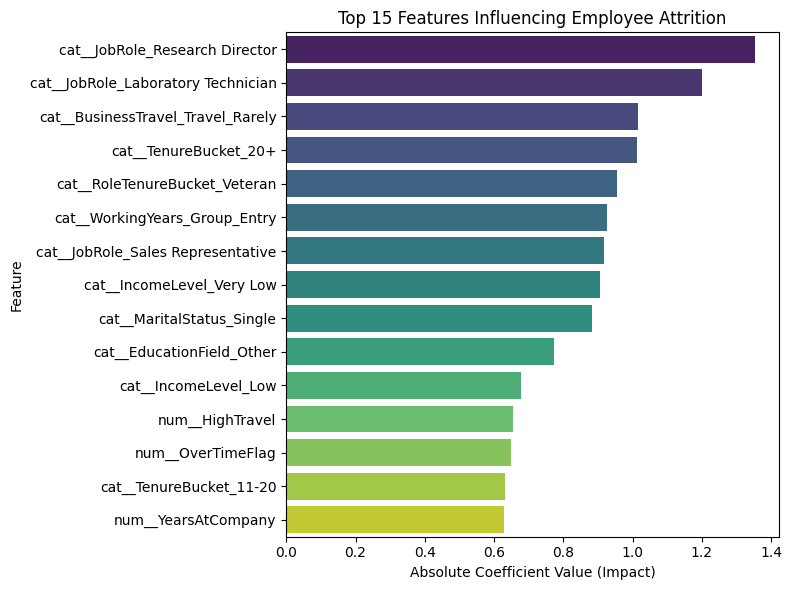

In [83]:
# -------------------- Feature Importance : Logistic Regression --------------------

# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients from the model
coefficients = lr_pipeline.named_steps['classifier'].coef_[0]

# Create DF
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Impact': abs(coefficients)
}).sort_values(by='Abs_Impact', ascending=False)

# Display top 15 most important features
print("-" * 80 + "\nTop 15 features driving attrition (Logistic Regression)\n" + "-" * 80)
display(feat_imp.head(15)[['Feature', 'Coefficient']].round(4))

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp.head(15), x='Abs_Impact', y='Feature', palette='viridis')
plt.title('Top 15 Features Influencing Employee Attrition')
plt.xlabel('Absolute Coefficient Value (Impact)')
plt.tight_layout()
plt.show()

In [84]:
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

prec, rec, thresh = precision_recall_curve(y_test, y_proba_lr)

# Test different thresholds
print("-" * 60 + "\nThreshold Tuning for Logistic Regression\n" + "-" * 60 + "\n")
for t in [0.25, 0.28, 0.30, 0.32, 0.35, 0.40, 0.50]:
    y_pred_t = (y_proba_lr >= t).astype(int)
    print(f"Threshold = {t:.2f}")
    print(classification_report(y_test, y_pred_t))
    print("-" * 60)

------------------------------------------------------------
Threshold Tuning for Logistic Regression
------------------------------------------------------------

Threshold = 0.25
              precision    recall  f1-score   support

           0       0.97      0.59      0.73       247
           1       0.29      0.89      0.44        47

    accuracy                           0.64       294
   macro avg       0.63      0.74      0.59       294
weighted avg       0.86      0.64      0.69       294

------------------------------------------------------------
Threshold = 0.28
              precision    recall  f1-score   support

           0       0.97      0.62      0.76       247
           1       0.31      0.89      0.46        47

    accuracy                           0.67       294
   macro avg       0.64      0.76      0.61       294
weighted avg       0.86      0.67      0.71       294

------------------------------------------------------------
Threshold = 0.30
         

In [113]:
# Top Positive (Increase Attrition) vs Negative (Decrease Attrition) drivers
feat_imp['Direction'] = feat_imp['Coefficient'].apply(lambda x: 'Increases Attrition' if x > 0 else 'Decreases Attrition')

print("-" * 80 + "\nTop drivers of attrition (Logistic Regression)\n" + "-" * 80)
print("\nTop 10 factors that increase attrition:\n")
print(feat_imp[feat_imp['Coefficient'] > 0].head(10)[['Feature', 'Coefficient']].round(4))

print("\n\nTop 10 factors that decrease attrition:\n")
print(feat_imp[feat_imp['Coefficient'] < 0].head(10)[['Feature', 'Coefficient']].round(4))

--------------------------------------------------------------------------------
Top drivers of attrition (Logistic Regression)
--------------------------------------------------------------------------------

Top 10 factors that increase attrition:

                               Feature  Coefficient
37  cat__JobRole_Laboratory Technician       1.1999
27   cat__BusinessTravel_Travel_Rarely       1.0161
61       cat__RoleTenureBucket_Veteran       0.9556
50       cat__WorkingYears_Group_Entry       0.9270
43   cat__JobRole_Sales Representative       0.9185
65           cat__IncomeLevel_Very Low       0.9048
45           cat__MaritalStatus_Single       0.8842
62                cat__IncomeLevel_Low       0.6768
21                     num__HighTravel       0.6548
22                   num__OverTimeFlag       0.6503


Top 10 factors that decrease attrition:

                              Feature  Coefficient
40     cat__JobRole_Research Director      -1.3546
56              cat__TenureBucke

In [114]:
# LightGBM Feature Importance

lgb_importance = lgb_pipeline.named_steps['classifier'].feature_importances_
feature_names = lgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

lgb_feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgb_importance
}).sort_values(by='Importance', ascending=False)

print("TOP 15 FEATURES - LightGBM")
print(lgb_feat_imp.head(15))

TOP 15 FEATURES - LightGBM
                          Feature  Importance
7              num__MonthlyIncome        1538
20    num__IncomePerYearOfService        1163
0                        num__Age         999
1           num__DistanceFromHome         883
9          num__PercentSalaryHike         718
8         num__NumCompaniesWorked         515
13         num__TotalWorkingYears         511
16            num__YearsAtCompany         468
19      num__YearsWithCurrManager         464
11  num__RelationshipSatisfaction         442
6            num__JobSatisfaction         433
3    num__EnvironmentSatisfaction         429
14     num__TrainingTimesLastYear         405
4             num__JobInvolvement         378
18   num__YearsSinceLastPromotion         355


In [87]:
y_proba_lgb = lgb_pipeline.predict_proba(X_test)[:, 1]

prec, rec, thresh = precision_recall_curve(y_test, y_proba_lgb)

# Test different thresholds
print("-" * 60 + "\nThreshold Tuning for LightGBM\n" + "-" * 60 + "\n")
for t in [0.25, 0.28, 0.30, 0.32, 0.35, 0.40, 0.50]:
    y_pred_t = (y_proba_lgb >= t).astype(int)
    print(f"Threshold = {t:.2f}")
    print(classification_report(y_test, y_pred_t))
    print("-" * 60)

------------------------------------------------------------
Threshold Tuning for LightGBM
------------------------------------------------------------

Threshold = 0.25
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.54      0.32      0.40        47

    accuracy                           0.85       294
   macro avg       0.71      0.63      0.66       294
weighted avg       0.82      0.85      0.83       294

------------------------------------------------------------
Threshold = 0.28
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.56      0.32      0.41        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294

------------------------------------------------------------
Threshold = 0.30
              precis

In [115]:
# Final model(Logistic Regression) with best threshold (0.30)
final_threshold = 0.30

# Probabilities
y_proba_final = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

print("Final model performance (Threshold = 0.30)")
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

# Saving predictions for analysis
results_df = pd.DataFrame({
    'Actual_Attrition': y_test,
    'Predicted_Attrition': y_pred_final,
    'Attrition_Probability': y_proba_final
})

print("\nSample Predictions:")
print(results_df.head(10))

Final model performance (Threshold = 0.30)
              precision    recall  f1-score   support

           0       0.96      0.65      0.77       247
           1       0.31      0.85      0.46        47

    accuracy                           0.68       294
   macro avg       0.64      0.75      0.62       294
weighted avg       0.86      0.68      0.72       294

ROC-AUC: 0.8289

Sample Predictions:
      Actual_Attrition  Predicted_Attrition  Attrition_Probability
1061                 0                    1               0.471151
891                  0                    0               0.014023
456                  0                    0               0.218144
922                  0                    0               0.017823
69                   1                    1               0.672286
1164                 0                    1               0.397790
406                  0                    0               0.053428
1330                 0                    0              

In [89]:
import joblib

# Save the model
joblib.dump(lr_pipeline, 'final_attrition_model_v1.pkl')
print("Model saved successfully")

# Save detailed predictions
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_final,
    'Probability': y_proba_final.round(4)
}).round(4)

results_df.to_csv('attrition_predictions_final.csv')
print("Predictions saved as 'attrition_predictions_final.csv'")

# Save feature importance
feat_imp.to_csv('feature_importance.csv', index=False)
print("Feature importance saved!")

Model saved successfully
Predictions saved as 'attrition_predictions_final.csv'
Feature importance saved!


In [105]:
# Create a clean version for PostgreSQL
final_df = df_model.copy()

# Add final predictions and risk flags
final_df['Attrition_Probability'] = lr_pipeline.predict_proba(X)[:, 1]
final_df['Predicted_Attrition'] = (final_df['Attrition_Probability'] >= 0.30).astype(int)
final_df['Risk_Level'] = final_df['Attrition_Probability'].apply(
                                                            lambda x: 'High' if x >= 0.40 else 'Medium' if x >= 0.30 else 'Low'
                                                                )

# Select important columns for the main table
columns_to_export = [
    'Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime',
    'YearsAtCompany', 'YearsInCurrentRole', 'MaritalStatus',
    'EducationField', 'BusinessTravel', 'Gender','Age_Group', 'TenureBucket', 
    'RoleTenureBucket','Attrition', 'Attrition_Probability', 
    'Predicted_Attrition', 'Risk_Level'
]

final_export = final_df[columns_to_export]

print("Final table shape for PostgreSQL:", final_export.shape)
final_export.head()

Final table shape for PostgreSQL: (1470, 18)


,Age,Department,JobRole,MonthlyIncome,OverTime,YearsAtCompany,YearsInCurrentRole,MaritalStatus,EducationField,BusinessTravel,Gender,Age_Group,TenureBucket,RoleTenureBucket,Attrition,Attrition_Probability,Predicted_Attrition,Risk_Level
0,41,Sales,Sales Executive,5993,Yes,6,4,Single,Life Sciences,Travel_Rarely,Female,Experienced Employees,6-10,Mid,1,0.879070,1,High
1,49,Research & Development,Research Scientist,5130,No,10,7,Married,Life Sciences,Travel_Frequently,Male,Senior Employees,6-10,Senior,0,0.068119,0,Low
2,37,Research & Development,Laboratory Technician,2090,Yes,0,0,Single,Other,Travel_Rarely,Male,Experienced Employees,0-2,New,1,0.795387,1,High
3,33,Research & Development,Research Scientist,2909,Yes,8,7,Married,Life Sciences,Travel_Frequently,Female,Adult Employees,6-10,Senior,0,0.450225,1,High
4,27,Research & Development,Laboratory Technician,3468,No,2,2,Married,Medical,Travel_Rarely,Male,Adult Employees,0-2,New,0,0.746552,1,High


In [107]:
from sqlalchemy import create_engine

username = 'your_username'
password = 'your_password'
host = 'localhost'
port = '1234'
database = 'ibm_hr_dataset'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Main HR table
final_export.to_sql('ibm_hr_attrition', engine, if_exists='replace', index=False)
print("Main table 'ibm_hr_dataset' exported")

# 2. Feature Importance table
feat_imp.to_sql('feature_importance', engine, if_exists='replace', index=False)
print("Feature importance table exported")

# 3. (Optional) Raw predictions for test set
results_df.to_sql('attrition_test_predictions', engine, if_exists='replace', index=False)
print("Test predictions table exported")

print("Data is successfully loaded into the table.")
print("Table names: \nibm_hr_attrition \nfeature_importance \nattrition_test_predictions ")
print(f"Total rows exported (final_export) : {final_export.shape[0]}")
print(f"Total rows exported (feat_imp) :     {feat_imp.shape[0]}")
print(f"Total rows exported (results_df) :   {results_df.shape[0]}")

Main table 'ibm_hr_dataset' exported
Feature importance table exported
Test predictions table exported
Data is successfully loaded into the table.
Table names: 
ibm_hr_attrition 
feature_importance 
attrition_test_predictions 
Total rows exported (final_export) : 1470
Total rows exported (feat_imp) :     66
Total rows exported (results_df) :   294
